# Analog-to-Digital Converters (ADCs)

This notebook is a tutorial-style introduction to **Analog-to-Digital Converters (ADCs)** and how we can estimate the ADC requirements needed to represent real signals digitally.

The main objective is to understand how a continuous analog signal, such as an EEG signal, voltage signal, or sensor recording, becomes a digital signal that can be stored and processed by a computer. To do this, the notebook covers the three main stages of analog-to-digital conversion:

1. **Sampling**, where we take measurements of the signal at discrete moments in time.
2. **Quantization**, where continuous amplitude values are assigned to discrete amplitude levels.
3. **Digital coding**, where each quantized level is represented using binary codes.

The notebook first explains the theoretical ideas behind ADCs, including the **Nyquist-Shannon sampling theorem**, aliasing, quantization levels, quantization error, dynamic range, and bit depth. It then moves into practical examples showing how to compute the number of bits required for an ADC when we know the signal range and the smallest amplitude change we want to resolve.

A major part of the notebook focuses on a realistic situation: **we only have signal data stored in CSV files**. In real life, this often happens when we receive EEG recordings, biomedical signals, sensor outputs, or experimental data without full information about the original acquisition system. In these cases, we may not know the original ADC range, the exact quantization step, or whether the data have already been filtered, rounded, normalized, or transformed. Therefore, the notebook shows how to estimate ADC requirements directly from the observed values in the data.

The processing approach used in the code is based on:

- Loading signal files from CSV.
- Extracting the signal values.
- Finding the minimum and maximum amplitude values.
- Computing the signal dynamic range.
- Finding the unique observed amplitude levels.
- Measuring the spacing between adjacent amplitude levels.
- Estimating the required quantization step, number of levels, and bit depth.
- Checking how many digital codes are available for the estimated bit depth.

This type of analysis is useful when we want to answer questions such as:

- What dynamic range should an ADC cover for this signal?
- What is the smallest amplitude difference we need to preserve?
- How many quantization levels are required?
- How many bits are needed to represent the signal with enough precision?
- Could two different signal values collapse into the same digital level?
- Is the observed signal compatible with a low-resolution or high-resolution ADC?

In practical biomedical or neuroscience contexts, this approximation can be useful when analyzing signals such as EEG, EMG, ECG, local field potentials, or sensor recordings. For example, if we are designing a data acquisition system for EEG, we need an ADC with enough resolution to detect very small voltage changes. If the bit depth is too low, the signal may lose important amplitude information due to quantization error. If the sampling rate is too low, the signal may suffer from aliasing and appear to contain false frequency components.

By the end of the notebook, the expected result is that we can take each signal, estimate its amplitude range, identify how finely its amplitude values need to be separated, and compute an approximate ADC bit depth. The final outputs include the signal range, adjacent amplitude spacings, smallest required quantization step, required number of quantization levels, required number of bits, and the number of available digital codes for that bit depth.

The goal is not always to recover the true original ADC configuration exactly, because this may be impossible from processed CSV data alone. Instead, the goal is to build a clear and practical method for estimating the ADC resolution that would be required to preserve the observed signal values without losing important amplitude distinctions.

* **Analog-to-Digital Converters (ADCs):** Provides a link between the analog world of continuously changing signals and the digital world of 0s and 1s.

## <span style="background-color:#d8f8d8; padding:4px;">Sampling </span>

Sampling is the first step in the analog-to-digital conversion process.

Before sampling, the signal is **continuous in time**. This means that, in theory, the signal has a value at every possible instant.

For example, an analog signal can be written as:

$$
x(t)
$$

where:

- $x$ is the signal amplitude.
- $t$ is continuous time.

In real life, this could represent:

- the voltage recorded from an EEG electrode,
- the voltage produced by a microphone,
- the output of a temperature sensor,
- the voltage measured from an ECG or EMG signal.

However, a computer cannot store infinitely many values from continuous time. Therefore, instead of recording the signal at every possible instant, we record it only at specific time points.

That process is called **sampling**.

During sampling, we take repeated measurements of the analog signal at regular time intervals. Each measurement is called a **sample**.

So, instead of storing the full continuous signal:

$$
x(t)
$$

we store a sequence of values:

$$
x[0], x[1], x[2], x[3], \dots
$$

Each value is a snapshot of the signal amplitude at one specific moment in time.

---

## <span style="background-color:#d8f8d8; padding:4px;">What happens during sampling?</span>

The sampling process can be understood in five steps.

### Step 1: Start with a continuous analog signal

The original signal changes continuously over time.

For example:

$$
x(t) = \sin(2\pi f t)
$$

This signal has a value at every possible time $t$.

The parameter $f$ is the frequency of the signal. Frequency tells us how fast something oscillates.

For example:

- 1 Hz = 1 cycle per second.
- 5 Hz = 5 cycles per second.
- 100 Hz = 100 cycles per second.

A higher-frequency signal oscillates faster.

Therefore, high-frequency signals require faster sampling rates.

---

### Step 2: Choose a sampling frequency

The **sampling frequency**, also called the **sampling rate**, tells us how many samples we take per second.

It is usually written as:

$$
f_s
$$

where:

- $f_s$ = sampling frequency,
- its unit is Hertz, Hz,
- 1 Hz means 1 sample per second.

For example:

- $f_s = 100$ Hz means 100 samples per second.
- $f_s = 500$ Hz means 500 samples per second.
- $f_s = 1000$ Hz means 1000 samples per second.

The sampling frequency is important because it determines how often we observe the signal.

If we sample very frequently, we capture many points from the signal, and the discrete sequence preserves the shape of the original signal better.

If we sample too slowly, we may miss important changes in the signal.

---

### Step 3: Compute the sampling interval

The **sampling interval** is the time between two consecutive samples.

It is usually written as:

$$
T_s
$$

and it is computed as:

$$
T_s = \frac{1}{f_s}
$$

For example, if:

$$
f_s = 100 \text{ Hz}
$$

then:

$$
T_s = \frac{1}{100} = 0.01 \text{ seconds}
$$

So we take one sample every 0.01 seconds.

---

### Step 4: Take samples at discrete time points

Once we choose the sampling interval, we measure the signal at times:

$$
t = 0, T_s, 2T_s, 3T_s, 4T_s, \dots
$$

Equivalently:

$$
t_n = nT_s
$$

where:

- $n$ is the sample index,
- $T_s$ is the sampling interval,
- $t_n$ is the time of the $n$-th sample.

The sampled signal is then:

$$
x[n] = x(nT_s)
$$

This means:

> The discrete sample $x[n]$ is the value of the original continuous signal $x(t)$ measured at time $t = nT_s$.

---

### Step 5: Obtain a discrete-time signal

After sampling, the signal is no longer continuous in time.

Instead of having values at every possible time, we now have values only at selected time points.

The result is a **discrete-time signal**:

$$
x[0], x[1], x[2], x[3], \dots
$$

Important:

At this stage, the signal is discrete in time, but the amplitude may still be continuous.

That means sampling answers the question:

> At what moments do we measure the signal?

It does **not yet** answer the question:

> How many amplitude levels can we represent?

That second question belongs to the next ADC step: **quantization**.

---

## <span style="background-color:#d8f8d8; padding:4px;">Why sampling frequency matters</span>

The sampling frequency determines whether we can correctly capture the changes in the signal.

For example, imagine a signal that oscillates very fast. If we take samples too far apart, we may miss several oscillations between two samples. As a result, the sampled signal may look like a different, slower signal.

This problem is called **aliasing**.

---

## <span style="background-color:#d8f8d8; padding:4px;">Aliasing</span>

Aliasing happens when a continuous signal is sampled at too low a sampling rate.

When aliasing occurs, the sampled signal can appear to contain false lower-frequency components that were not actually present in the original signal.

A useful analogy is a car wheel recorded by a camera.

If the wheel spins very fast, but the camera records only a few frames per second, the camera misses most of the wheel's rotation. As a result, the wheel may appear to move slowly, stop, or even rotate backward.

That apparent slow or backward motion is not the true motion of the wheel. It is a false pattern created by insufficient sampling.

In signal processing, that false pattern is called an **alias**.

---

## <span style="background-color:#d8f8d8; padding:4px;">Nyquist-Shannon Sampling Theorem</span>

The Nyquist-Shannon sampling theorem tells us the minimum sampling rate needed to avoid aliasing.

If a continuous signal contains no frequencies higher than:

$$
f_{\max}
$$

then the signal can be reconstructed from its samples if the sampling frequency satisfies:

$$
f_s \geq 2f_{\max}
$$

where:

- $f_s$ = sampling frequency, in samples per second,
- $f_{\max}$ = highest frequency present in the signal,
- $2f_{\max}$ = Nyquist rate.

The value:

$$
2f_{\max}
$$

is called the **Nyquist rate**.

This means that we need at least two samples per cycle of the fastest oscillation in the signal.

---

### <u>Intuition: Why do we need at least 2 samples per cycle?</u>

Imagine one full sine wave cycle.

If you take only one sample per cycle, you are in trouble:

- Every sample might land at the same phase.
- The signal may look constant.
- You may completely miss the oscillation.

If you take two samples per cycle, that is the minimum needed to distinguish the oscillation in principle.

That is why the critical boundary is:

$$
f_s = 2f_{\max}
$$

In practice, people often sample faster than this minimum.

---

## <span style="background-color:#d8f8d8; padding:4px;">Worked example: sampling a 5 Hz signal</span>

Let us use one simple signal to compare correct sampling and aliasing.

Take this signal:

$$
x(t) = \sin(2\pi \cdot 5t)
$$

This is a sine wave with frequency:

$$
f = 5 \text{ Hz}
$$

So the highest frequency is:

$$
f_{\max} = 5 \text{ Hz}
$$

By the Nyquist-Shannon theorem, we need:

$$
f_s \geq 2f_{\max}
$$

Therefore:

$$
f_s \geq 2(5) = 10 \text{ Hz}
$$

So, for this signal, the Nyquist rate is:

$$
10 \text{ Hz}
$$

Now we can compare two cases:

1. Safe sampling, where the sampling frequency is above the Nyquist rate.
2. Undersampling, where the sampling frequency is below the Nyquist rate.

---

### <u>Example 1: Safe sampling above the Nyquist rate</u>

Let us sample the 5 Hz signal at:

$$
f_s = 20 \text{ Hz}
$$

This is above the Nyquist rate:

$$
20 \text{ Hz} > 10 \text{ Hz}
$$

So this sampling rate is safe.

The sampling interval is:

$$
T_s = \frac{1}{f_s}
$$

Therefore:

$$
T_s = \frac{1}{20} = 0.05 \text{ s}
$$

This means we take one sample every 0.05 seconds.

We sample at times:

$$
t = 0, 0.05, 0.10, 0.15, 0.20, \dots
$$

Now we compute the sampled values:

$$
x(0) = \sin(2\pi \cdot 5 \cdot 0) = \sin(0) = 0
$$

$$
x(0.05) = \sin(2\pi \cdot 5 \cdot 0.05) = \sin\left(\frac{\pi}{2}\right) = 1
$$

$$
x(0.10) = \sin(2\pi \cdot 5 \cdot 0.10) = \sin(\pi) = 0
$$

$$
x(0.15) = \sin(2\pi \cdot 5 \cdot 0.15) = \sin\left(\frac{3\pi}{2}\right) = -1
$$

$$
x(0.20) = \sin(2\pi \cdot 5 \cdot 0.20) = \sin(2\pi) = 0
$$

The resulting sequence is:

$$
0, 1, 0, -1, 0, 1, \dots
$$

This sequence clearly represents the oscillation.

Since:

$$
20 \text{ Hz} > 10 \text{ Hz}
$$

the sampling frequency is above the Nyquist rate, so aliasing is avoided.

---

### <u>Example 2: Aliasing below the Nyquist rate</u>

Now let us sample the same 5 Hz signal at:

$$
f_s = 6 \text{ Hz}
$$

This is below the Nyquist rate:

$$
6 \text{ Hz} < 10 \text{ Hz}
$$

So this sampling rate is too low.

The sampling interval is:

$$
T_s = \frac{1}{6} \approx 0.1667 \text{ s}
$$

This means we take one sample approximately every 0.1667 seconds.

We sample at times:

$$
t = 0, 0.1667, 0.3333, 0.5000, \dots
$$

Now we compute the sampled values:

$$
x(0) = \sin(0) = 0
$$

$$
x(0.1667) = \sin(2\pi \cdot 5 \cdot 0.1667) \approx \sin(1.6667\pi)
$$

$$
x(0.3333) = \sin(2\pi \cdot 5 \cdot 0.3333) \approx \sin(3.3333\pi)
$$

Because the sampling rate is too low, these sampled points can look like they belong to a different, lower-frequency wave.

The samples no longer correctly describe the original 5 Hz signal.

This is **aliasing**.

---

## <span style="background-color:#d8f8d8; padding:4px;">Practical example: choosing a sampling rate </span>

Suppose the highest frequency in a signal is:

$$
f_{\max} = 40 \text{ Hz}
$$

Then the Nyquist rate is:

$$
2f_{\max} = 2(40) = 80 \text{ Hz}
$$

So the sampling frequency should be at least:

$$
f_s \geq 80 \text{ Hz}
$$

In practice, we often choose a sampling frequency higher than the theoretical minimum, such as 100 Hz, 200 Hz, or more, because real signals may contain noise, filtering effects, or unexpected high-frequency components.

---

## <span style="background-color:#d8f8d8; padding:4px;">Summary</span>

Sampling converts a continuous-time signal into a discrete-time signal.

Before sampling:

$$
x(t)
$$

After sampling:

$$
x[n] = x(nT_s)
$$

where:

$$
T_s = \frac{1}{f_s}
$$

Sampling determines **when** we measure the signal.

Quantization, which comes later, determines **how precisely** we represent the amplitude of each sample.

The key idea is:

> To avoid aliasing, the sampling frequency must be at least twice the highest frequency present in the signal.

That is:

$$
f_s \geq 2f_{\max}
$$

## <span style="background-color:#d8f8d8; padding:4px;">Sampling Example:</span>

In the following code, we simulate the sampling stage of analog-to-digital conversion. First, we create a high-resolution signal that represents the original continuous analog signal. Then, we choose a sampling frequency and take amplitude measurements only at specific time points. The result is a discrete-time sequence of samples.

At this stage, the signal has been sampled in time, but it has not yet been quantized in amplitude. Quantization will be the next step.

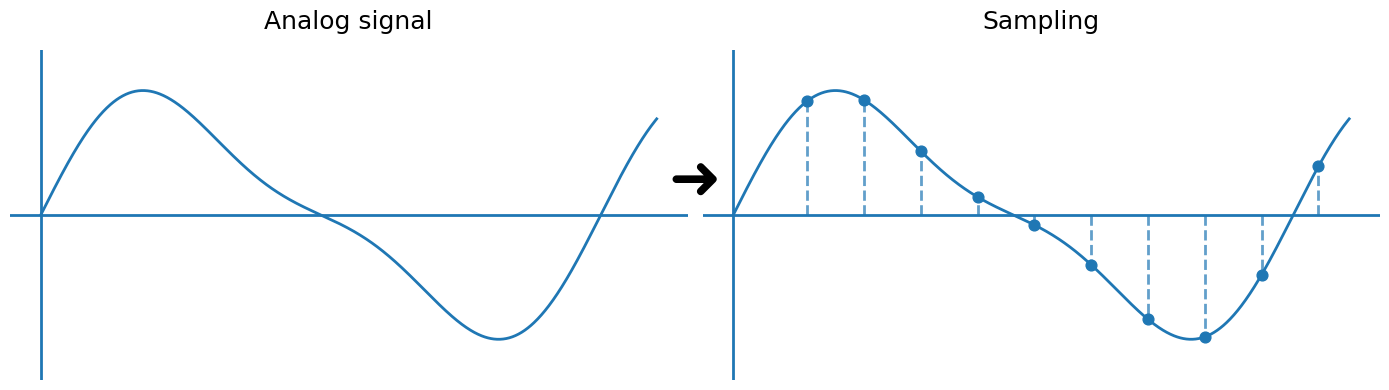

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Recreate the conceptual sampling image using Python
# ------------------------------------------------------------
# This figure illustrates the main idea of sampling:
#
# Left:
#   A continuous analog signal x(t)
#
# Right:
#   The same signal measured only at discrete time points
#
# Each purple point is one sample.
# The dashed vertical lines show the sampling instants.
# ------------------------------------------------------------

def plot_sampling_concept_image():
    """
    Recreate a conceptual image of analog signal sampling.

    This function does not perform the full ADC process.
    It only illustrates the first step: sampling.

    Sampling converts:
        continuous-time signal x(t)

    into:
        discrete-time samples x[n] = x(nTs)
    """

    # --------------------------------------------------------
    # Create a smooth signal for visualization
    # --------------------------------------------------------
    # We use a smooth artificial waveform.
    # It is not meant to represent a specific real EEG signal.
    # It is just useful for explaining the concept visually.

    t = np.linspace(0, 1, 1000)

    # Smooth analog-looking signal.
    # This combines sine waves to create a shape similar to the image.
    x = (
        0.8 * np.sin(2 * np.pi * 1.1 * t)
        + 0.25 * np.sin(2 * np.pi * 2.2 * t)
    )

    # Shift the signal upward so it starts near the horizontal axis.
    x = x - x[0]

    # --------------------------------------------------------
    # Choose sampling time points
    # --------------------------------------------------------
    # These are the times at which we "measure" the signal.

    t_samples = np.linspace(0.12, 0.95, 10)

    # Compute the sampled amplitude values from the same signal.
    # np.interp allows us to evaluate the signal at those sample times.
    x_samples = np.interp(t_samples, t, x)

    # --------------------------------------------------------
    # Create figure with two panels
    # --------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax_left = axes[0]
    ax_right = axes[1]

    # --------------------------------------------------------
    # Left panel: analog signal
    # --------------------------------------------------------

    ax_left.plot(t, x, linewidth=2)

    # Draw simple x and y axes manually
    ax_left.axhline(0, linewidth=2)
    ax_left.axvline(0, linewidth=2)

    ax_left.set_title("Analog signal", fontsize=18, pad=15)

    # Remove ticks and box to mimic a clean conceptual drawing
    ax_left.set_xticks([])
    ax_left.set_yticks([])
    for spine in ax_left.spines.values():
        spine.set_visible(False)

    ax_left.set_xlim(-0.05, 1.05)
    ax_left.set_ylim(min(x) - 0.3, max(x) + 0.3)

    # --------------------------------------------------------
    # Right panel: sampled signal
    # --------------------------------------------------------

    ax_right.plot(t, x, linewidth=2)

    # Draw sampled points
    ax_right.scatter(t_samples, x_samples, s=60, zorder=3)

    # Draw vertical dashed lines from x-axis to each sample
    for ts, xs in zip(t_samples, x_samples):
        ax_right.vlines(
            ts,
            0,
            xs,
            linestyles="dashed",
            linewidth=2,
            alpha=0.7
        )

    # Draw simple x and y axes manually
    ax_right.axhline(0, linewidth=2)
    ax_right.axvline(0, linewidth=2)

    ax_right.set_title("Sampling", fontsize=18, pad=15)

    # Remove ticks and box
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    for spine in ax_right.spines.values():
        spine.set_visible(False)

    ax_right.set_xlim(-0.05, 1.05)
    ax_right.set_ylim(min(x) - 0.3, max(x) + 0.3)

    # --------------------------------------------------------
    # Add orange arrow between panels
    # --------------------------------------------------------
    # fig.text places text in figure coordinates.
    # The arrow symbol visually connects analog signal -> sampling.

    fig.text(
        0.5,
        0.53,
        "➜",
        fontsize=45,
        ha="center",
        va="center"
    )

    plt.tight_layout()
    plt.show()


plot_sampling_concept_image()

In [3]:
# ------------------------------------------------------------
# 2. Sampling demonstration function
# ------------------------------------------------------------
# This code demonstrates the sampling step more quantitatively.
#
# It shows:
#   1. A continuous-looking signal.
#   2. The sampled points.
#   3. The sampled sequence.
#   4. Whether the chosen sampling frequency satisfies Nyquist.
# ------------------------------------------------------------

def demonstrate_sampling(signal_frequency=5, fs=25, duration=1.0):
    """
    Demonstrate how a continuous-looking analog signal is sampled.

    Parameters
    ----------
    signal_frequency : float
        Frequency of the analog sine wave in Hz.

    fs : float
        Sampling frequency in samples per second.

    duration : float
        Duration of the signal in seconds.

    Returns
    -------
    t_sampled : numpy.ndarray
        Time points where the signal was sampled.

    x_sampled : numpy.ndarray
        Amplitude values measured at the sampled time points.
    """

    # --------------------------------------------------------
    # Step A: Create a continuous-looking analog signal
    # --------------------------------------------------------
    # In a computer, we cannot represent a truly continuous signal.
    # So we approximate it using many very closely spaced points.
    #
    # This high-resolution signal is only used for visualization.

    high_resolution_fs = 5000

    t_continuous = np.linspace(
        0,
        duration,
        int(high_resolution_fs * duration),
        endpoint=False
    )

    x_continuous = np.sin(2 * np.pi * signal_frequency * t_continuous)

    # --------------------------------------------------------
    # Step B: Choose the sampling interval
    # --------------------------------------------------------
    # The sampling interval Ts is the time between samples:
    #
    #   Ts = 1 / fs

    Ts = 1 / fs

    # --------------------------------------------------------
    # Step C: Create sampling time points
    # --------------------------------------------------------
    # These are the time points where we measure the signal:
    #
    #   t_n = nTs

    t_sampled = np.arange(0, duration, Ts)

    # --------------------------------------------------------
    # Step D: Measure the signal at those time points
    # --------------------------------------------------------
    # The sampled signal is:
    #
    #   x[n] = x(nTs)

    x_sampled = np.sin(2 * np.pi * signal_frequency * t_sampled)

    # --------------------------------------------------------
    # Step E: Compute the Nyquist rate
    # --------------------------------------------------------
    # Since this signal contains only one frequency:
    #
    #   fmax = signal_frequency
    #
    # Therefore:
    #
    #   Nyquist rate = 2 * fmax

    nyquist_rate = 2 * signal_frequency

    # --------------------------------------------------------
    # Step F: Plot continuous signal with samples
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.plot(
        t_continuous,
        x_continuous,
        label="Original analog signal: x(t)"
    )

    plt.scatter(
        t_sampled,
        x_sampled,
        label="Samples: x[n] = x(nTs)",
        zorder=3
    )

    for t, x in zip(t_sampled, x_sampled):
        plt.vlines(
            t,
            0,
            x,
            linestyles="dashed",
            alpha=0.4
        )

    plt.plot(
        t_sampled,
        x_sampled,
        linestyle="--",
        label="Signal suggested by samples"
    )

    plt.title(f"Sampling a {signal_frequency} Hz signal at fs = {fs} Hz")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Step G: Plot only the sampled sequence
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.stem(
        t_sampled,
        x_sampled,
        basefmt=" "
    )

    plt.title("Output of sampling: discrete-time samples")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Sampled amplitude")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Step H: Print interpretation
    # --------------------------------------------------------

    print("Signal frequency:", signal_frequency, "Hz")
    print("Sampling frequency fs:", fs, "Hz")
    print("Sampling interval Ts:", Ts, "seconds")
    print("Nyquist rate:", nyquist_rate, "Hz")
    print("Number of samples collected:", len(x_sampled))

    if fs >= nyquist_rate:
        print("Result: Sampling rate is high enough according to Nyquist.")
        print("Interpretation: The sampled points preserve the oscillation pattern.")
    else:
        print("Result: Sampling rate is too low.")
        print("Interpretation: Aliasing may occur. The samples may suggest a false lower-frequency signal.")

    return t_sampled, x_sampled

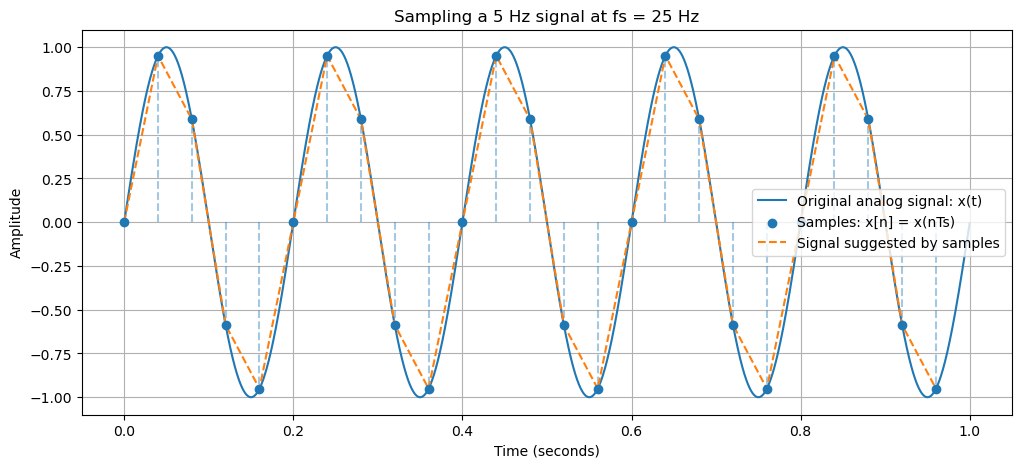

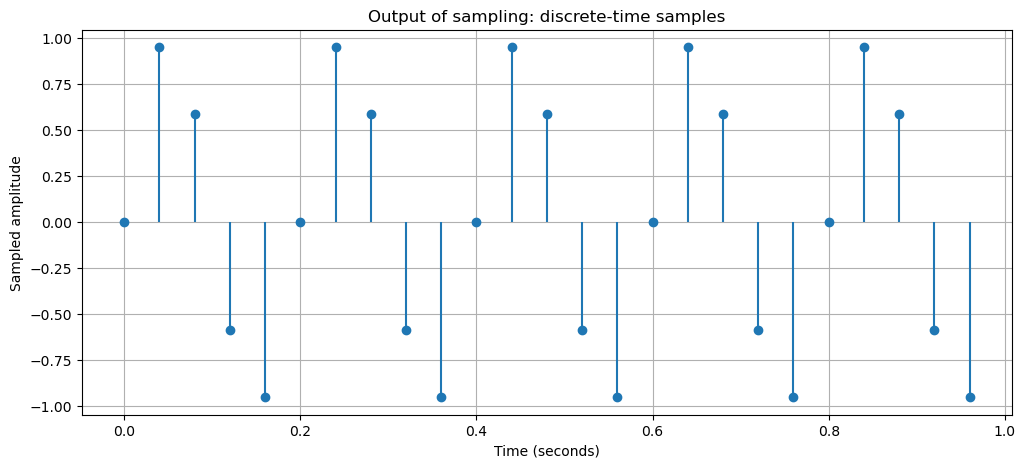

Signal frequency: 5 Hz
Sampling frequency fs: 25 Hz
Sampling interval Ts: 0.04 seconds
Nyquist rate: 10 Hz
Number of samples collected: 25
Result: Sampling rate is high enough according to Nyquist.
Interpretation: The sampled points preserve the oscillation pattern.


In [4]:
# Good sampling example
# Signal frequency = 5 Hz
# Nyquist rate = 10 Hz
# fs = 25 Hz is above the Nyquist rate.

t_good, x_good = demonstrate_sampling(
    signal_frequency=5,
    fs=25,
    duration=1.0
)

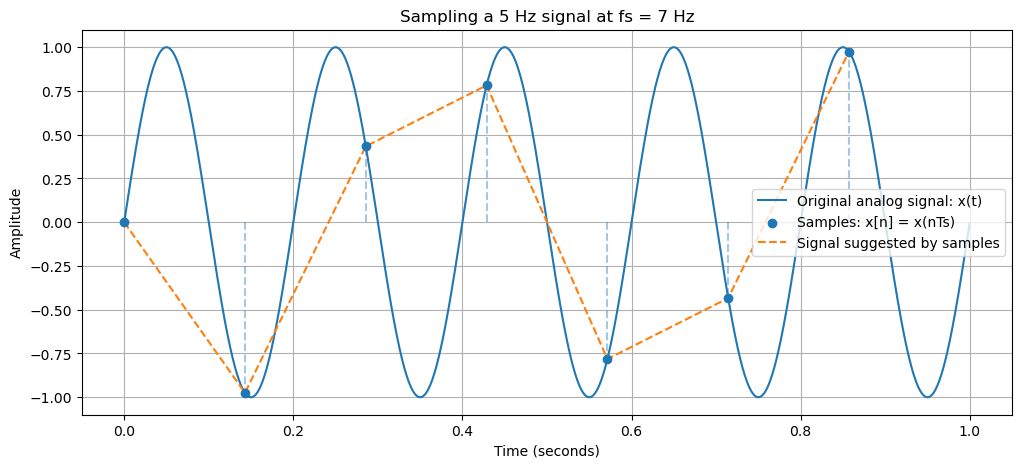

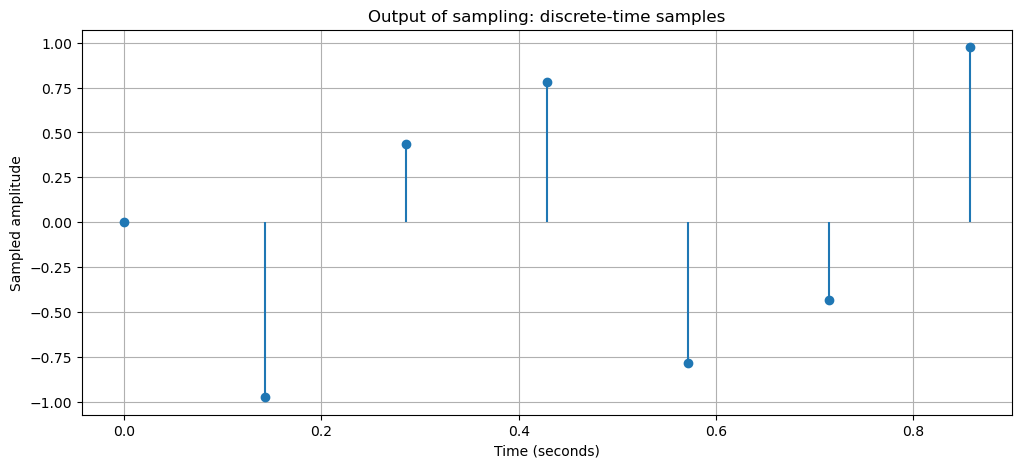

Signal frequency: 5 Hz
Sampling frequency fs: 7 Hz
Sampling interval Ts: 0.14285714285714285 seconds
Nyquist rate: 10 Hz
Number of samples collected: 7
Result: Sampling rate is too low.
Interpretation: Aliasing may occur. The samples may suggest a false lower-frequency signal.


In [5]:
# Bad sampling example
# Signal frequency = 5 Hz
# Nyquist rate = 10 Hz
# fs = 7 Hz is below the Nyquist rate.
# Therefore, aliasing may occur.

t_bad, x_bad = demonstrate_sampling(
    signal_frequency=5,
    fs=7,
    duration=1.0
)

## <span style="background-color:#d8f8d8; padding:4px;">Quantization</span>

After **sampling**, we have a signal that is discrete in time.

That means we no longer have the full continuous signal:

$$
x(t)
$$

Instead, we have samples taken at specific time points:

$$
x[n] = x(nT_s)
$$

However, after sampling, the amplitude values can still be continuous.

For example, a sampled signal may contain values like:

$$
0.134782,\quad 0.139921,\quad 0.141006,\quad 0.136554
$$

These values are discrete in time, but their amplitudes are not yet restricted to a fixed set of levels.

The next step is **quantization**.

---

## <span style="background-color:#d8f8d8; padding:4px;">What is quantization?</span>

Quantization is the process of converting continuous amplitude values into a finite set of discrete amplitude levels.

Sampling answers the question:

> At what times do we measure the signal?

Quantization answers the question:

> What amplitude values are we allowed to represent?

So, during quantization, each sampled amplitude is rounded or assigned to the nearest available amplitude level.

Before quantization:

$$
x[n]
$$

After quantization:

$$
x_q[n]
$$

where:

- $x[n]$ is the sampled amplitude before quantization,
- $x_q[n]$ is the quantized amplitude after assigning it to a discrete level.

---

## <span style="background-color:#d8f8d8; padding:4px;">Step-by-step idea</span>

### Step 1: Start with sampled values

After sampling, we have a sequence of measured values:

$$
x[0], x[1], x[2], x[3], \dots
$$

Each value is the amplitude of the signal at one sampling time.

Example:

$$
x[0] = 0.12
$$

$$
x[1] = 0.47
$$

$$
x[2] = 0.83
$$

$$
x[3] = -0.21
$$

At this point, these values can still take many possible decimal values.

---

### Step 2: Define the ADC input range

The ADC can only represent amplitudes inside a certain range.

For example:

$$
V_{\min} = -1
$$

$$
V_{\max} = 1
$$

So the full input range is:

$$
R = V_{\max} - V_{\min}
$$

In this example:

$$
R = 1 - (-1) = 2
$$

This means the ADC is designed to represent values between -1 and 1.

---

### Step 3: Choose the number of bits

The ADC resolution is usually described by the number of bits:

$$
n
$$

An ADC with $n$ bits can represent:

$$
2^n
$$

different digital codes or quantization levels.

For example:

- A 1-bit ADC has $2^1 = 2$ levels.
- A 2-bit ADC has $2^2 = 4$ levels.
- A 3-bit ADC has $2^3 = 8$ levels.
- A 10-bit ADC has $2^{10} = 1024$ levels.
- A 16-bit ADC has $2^{16} = 65536$ levels.

So, if we use a 3-bit ADC, the amplitude axis is divided into 8 possible levels.

---

### Step 4: Divide the amplitude range into discrete levels

Once we know the range and the number of levels, we can divide the y-axis into discrete steps.

The quantization step size is usually written as:

$$
\Delta
$$

A simple approximation is:

$$
\Delta = \frac{R}{L}
$$

where:

- $\Delta$ = quantization step size,
- $R$ = input range,
- $L$ = number of quantization levels,
- $L = 2^n$.

Sometimes, depending on the convention, we use:

$$
\Delta = \frac{R}{L - 1}
$$

This difference depends on whether we are thinking in terms of intervals or exact representable levels.

The important intuition is:

> More bits means more levels, and more levels means smaller spacing between amplitude values.

So, increasing the bit depth makes the ADC more precise.

---

### Step 5: Assign each sample to the nearest level

Each sampled value is replaced by the closest available quantization level.

For example, suppose the available levels are:

$$
-1.0,\quad -0.5,\quad 0.0,\quad 0.5,\quad 1.0
$$

If one sample is:

$$
x[n] = 0.43
$$

then it may be assigned to:

$$
x_q[n] = 0.5
$$

because 0.5 is the closest available level.

If another sample is:

$$
x[n] = -0.18
$$

then it may be assigned to:

$$
x_q[n] = 0.0
$$

because 0.0 is the closest available level.

This assignment is the core of quantization.

---

## <span style="background-color:#d8f8d8; padding:4px;">Quantization error</span>

Because the original sampled value is usually not exactly equal to one of the allowed levels, quantization introduces an error.

This error is called **quantization error**.

It is the difference between the original sampled value and the quantized value:

$$
e[n] = x[n] - x_q[n]
$$

where:

- $e[n]$ = quantization error,
- $x[n]$ = original sampled amplitude,
- $x_q[n]$ = quantized amplitude.

Example:

If:

$$
x[n] = 0.43
$$

and:

$$
x_q[n] = 0.5
$$

then:

$$
e[n] = 0.43 - 0.5 = -0.07
$$

So the quantization error is:

$$
-0.07
$$

This means the quantized value is 0.07 units higher than the original sampled value.

---

## <span style="background-color:#d8f8d8; padding:4px;">Quantization noise</span>

When we look at all quantization errors across the whole signal, the error behaves like an additional unwanted signal.

This is often called **quantization noise**.

The smaller the quantization step $\Delta$, the smaller the quantization error tends to be.

Therefore:

- low bit depth produces fewer levels,
- fewer levels produce larger amplitude jumps,
- larger jumps produce more quantization error,
- more quantization error means a less precise digital representation.

In contrast:

- high bit depth produces more levels,
- more levels produce smaller amplitude jumps,
- smaller jumps produce less quantization error,
- less quantization error means a more precise digital representation.

---

## <span style="background-color:#d8f8d8; padding:4px;">Example: 3-bit ADC</span>

Suppose we have a 3-bit ADC.

The number of levels is:

$$
L = 2^3 = 8
$$

This means the ADC can represent 8 different amplitude levels.

If the ADC range is from:

$$
V_{\min} = -1
$$

to:

$$
V_{\max} = 1
$$

then the range is:

$$
R = 1 - (-1) = 2
$$

Using the approximation:

$$
\Delta = \frac{R}{L}
$$

we get:

$$
\Delta = \frac{2}{8} = 0.25
$$

So the ADC divides the amplitude axis into steps of approximately 0.25 units.

A sampled value such as:

$$
x[n] = 0.37
$$

would be assigned to the nearest available level.

For example, if the nearest level is:

$$
x_q[n] = 0.25
$$

then the quantization error is:

$$
e[n] = 0.37 - 0.25 = 0.12
$$

---

## <span style="background-color:#d8f8d8; padding:4px;">Summary</span>

Sampling and quantization solve different parts of the analog-to-digital conversion problem.

Sampling makes the signal discrete in time:

$$
x(t) \rightarrow x[n]
$$

Quantization makes the signal discrete in amplitude:

$$
x[n] \rightarrow x_q[n]
$$

So the complete idea is:

$$
\text{continuous-time, continuous-amplitude signal}
$$

becomes:

$$
\text{discrete-time, discrete-amplitude signal}
$$

Sampling decides **when** we measure.

Quantization decides **which amplitude values** we are allowed to store.

The number of bits determines how many amplitude levels are available:

$$
L = 2^n
$$

More bits give more quantization levels, smaller quantization error, and a more accurate digital representation of the original signal.

## <span style="background-color:#d8f8d8; padding:4px;"> Quantization example:</span>

In this section, we visualize the quantization process.

After sampling, the signal is already discrete in time. However, the amplitude values may still be continuous decimal values. Quantization forces those sampled amplitudes into a finite set of allowed amplitude levels.

The horizontal lines represent the quantization levels. Each sampled value is moved to the nearest allowed level. The difference between the original sampled value and the quantized value is the quantization error.

Therefore:

$$
x[n] \rightarrow x_q[n]
$$

where:

- $x[n]$ is the sampled value before quantization,
- $x_q[n]$ is the quantized value,
- $e[n] = x[n] - x_q[n]$ is the quantization error.

Sampling makes the signal discrete in time. Quantization makes the signal discrete in amplitude.

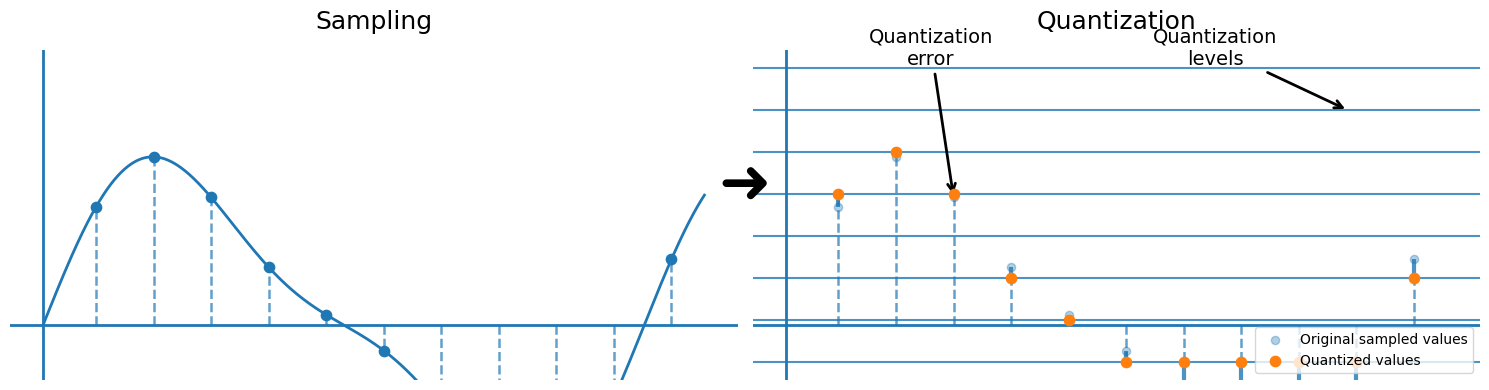

Number of bits: 3
Number of quantization levels: 8
Quantization levels:
[-0.2         0.02857143  0.25714286  0.48571429  0.71428571  0.94285714
  1.17142857  1.4       ]

First few sampled values:
[0.64359775 0.91659262 0.69611145 0.31533242 0.05626467]

First few quantized values:
[0.71428571 0.94285714 0.71428571 0.25714286 0.02857143]

First few quantization errors:
[-0.07068796 -0.02626452 -0.01817426  0.05818956  0.02769324]


In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Conceptual figure: Sampling -> Quantization
# ------------------------------------------------------------

def plot_quantization_concept_image():
    """
    Recreate a conceptual image of the quantization process.

    Left:
        A sampled signal.
        The signal is already discrete in time.

    Right:
        The sampled amplitudes are forced into discrete amplitude levels.
        The difference between original sampled values and quantized values
        is the quantization error.
    """

    # --------------------------------------------------------
    # Create a smooth analog-looking signal
    # --------------------------------------------------------

    t = np.linspace(0, 1, 1000)

    x = (
        0.8 * np.sin(2 * np.pi * 1.1 * t)
        + 0.25 * np.sin(2 * np.pi * 2.2 * t)
    )

    # Shift signal so it starts near zero
    x = x - x[0]

    # --------------------------------------------------------
    # Create sampled points
    # --------------------------------------------------------

    t_samples = np.linspace(0.08, 0.95, 11)
    x_samples = np.interp(t_samples, t, x)

    # --------------------------------------------------------
    # Define quantization levels
    # --------------------------------------------------------
    # These are the only allowed amplitude values after quantization.

    n_bits = 3
    n_levels = 2 ** n_bits

    x_min = -0.2
    x_max = 1.4

    quantization_levels = np.linspace(x_min, x_max, n_levels)

    # --------------------------------------------------------
    # Quantize each sampled value
    # --------------------------------------------------------
    # For every sampled amplitude, find the closest quantization level.

    x_quantized = []

    for value in x_samples:
        closest_level_index = np.argmin(np.abs(quantization_levels - value))
        closest_level = quantization_levels[closest_level_index]
        x_quantized.append(closest_level)

    x_quantized = np.array(x_quantized)

    # Quantization error
    quantization_error = x_samples - x_quantized

    # --------------------------------------------------------
    # Create figure with two panels
    # --------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    ax_left = axes[0]
    ax_right = axes[1]

    # --------------------------------------------------------
    # Left panel: sampled signal
    # --------------------------------------------------------

    ax_left.plot(t, x, linewidth=2)
    ax_left.scatter(t_samples, x_samples, s=55, zorder=3)

    for ts, xs in zip(t_samples, x_samples):
        ax_left.vlines(
            ts,
            0,
            xs,
            linestyles="dashed",
            linewidth=1.8,
            alpha=0.7
        )

    ax_left.axhline(0, linewidth=2)
    ax_left.axvline(0, linewidth=2)

    ax_left.set_title("Sampling", fontsize=18, pad=15)

    ax_left.set_xticks([])
    ax_left.set_yticks([])

    for spine in ax_left.spines.values():
        spine.set_visible(False)

    ax_left.set_xlim(-0.05, 1.05)
    ax_left.set_ylim(x_min - 0.1, x_max + 0.1)

    # --------------------------------------------------------
    # Right panel: quantization
    # --------------------------------------------------------

    # Draw horizontal quantization levels
    for level in quantization_levels:
        ax_right.axhline(
            level,
            linewidth=1.5,
            alpha=0.8
        )

    # Draw original sampled points as faint points
    ax_right.scatter(
        t_samples,
        x_samples,
        s=35,
        alpha=0.35,
        label="Original sampled values",
        zorder=2
    )

    # Draw quantized points
    ax_right.scatter(
        t_samples,
        x_quantized,
        s=55,
        label="Quantized values",
        zorder=4
    )

    # Draw vertical dashed sampling lines
    for ts, xq in zip(t_samples, x_quantized):
        ax_right.vlines(
            ts,
            0,
            xq,
            linestyles="dashed",
            linewidth=1.8,
            alpha=0.7
        )

    # Draw quantization error as small vertical segments
    for ts, xs, xq in zip(t_samples, x_samples, x_quantized):
        ax_right.vlines(
            ts,
            xq,
            xs,
            linewidth=3,
            alpha=0.8
        )

    ax_right.axhline(0, linewidth=2)
    ax_right.axvline(0, linewidth=2)

    ax_right.set_title("Quantization", fontsize=18, pad=15)

    ax_right.set_xticks([])
    ax_right.set_yticks([])

    for spine in ax_right.spines.values():
        spine.set_visible(False)

    ax_right.set_xlim(-0.05, 1.05)
    ax_right.set_ylim(x_min - 0.1, x_max + 0.1)

    # --------------------------------------------------------
    # Add annotations
    # --------------------------------------------------------

    ax_right.annotate(
        "Quantization\nlevels",
        xy=(0.85, quantization_levels[-2]),
        xytext=(0.65, x_max + 0.02),
        arrowprops=dict(arrowstyle="->", linewidth=2),
        fontsize=14,
        ha="center"
    )

    ax_right.annotate(
        "Quantization\nerror",
        xy=(t_samples[2], x_samples[2]),
        xytext=(0.22, x_max + 0.02),
        arrowprops=dict(arrowstyle="->", linewidth=2),
        fontsize=14,
        ha="center"
    )

    ax_right.legend(loc="lower right")

    # Arrow between panels
    fig.text(
        0.5,
        0.52,
        "➜",
        fontsize=45,
        ha="center",
        va="center"
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Print explanation
    # --------------------------------------------------------

    print("Number of bits:", n_bits)
    print("Number of quantization levels:", n_levels)
    print("Quantization levels:")
    print(quantization_levels)
    print()
    print("First few sampled values:")
    print(x_samples[:5])
    print()
    print("First few quantized values:")
    print(x_quantized[:5])
    print()
    print("First few quantization errors:")
    print(quantization_error[:5])


plot_quantization_concept_image()

Now here is a more explicit tutorial example using a sine wave, so the steps are easier to connect with the sampling example.

In [ ]:
# ------------------------------------------------------------
# 2. Full quantization demonstration function
# ------------------------------------------------------------

def demonstrate_quantization(signal_frequency=5, fs=25, duration=1.0, n_bits=3):
    """
    Demonstrate quantization after sampling.

    Parameters
    ----------
    signal_frequency : float
        Frequency of the original analog signal in Hz.

    fs : float
        Sampling frequency in samples per second.

    duration : float
        Duration of the signal in seconds.

    n_bits : int
        Number of ADC bits.

    Returns
    -------
    t_sampled : numpy.ndarray
        Sampling time points.

    x_sampled : numpy.ndarray
        Original sampled amplitude values.

    x_quantized : numpy.ndarray
        Quantized amplitude values.

    quantization_error : numpy.ndarray
        Difference between sampled and quantized values.
    """

    # --------------------------------------------------------
    # Step 1: Create a continuous-looking analog signal
    # --------------------------------------------------------
    # This is only for visualization.
    # A real analog signal would be continuous in time.

    high_resolution_fs = 5000

    t_continuous = np.linspace(
        0,
        duration,
        int(high_resolution_fs * duration),
        endpoint=False
    )

    x_continuous = np.sin(2 * np.pi * signal_frequency * t_continuous)

    # --------------------------------------------------------
    # Step 2: Sample the signal
    # --------------------------------------------------------
    # Sampling makes the signal discrete in time.
    #
    # Ts = 1 / fs

    Ts = 1 / fs

    t_sampled = np.arange(0, duration, Ts)

    x_sampled = np.sin(2 * np.pi * signal_frequency * t_sampled)

    # --------------------------------------------------------
    # Step 3: Define the quantization range
    # --------------------------------------------------------
    # The ADC must have a minimum and maximum amplitude range.
    #
    # Here we choose the range based on the signal.
    # Since a sine wave goes from -1 to 1, we use:
    #
    # Vmin = -1
    # Vmax = 1

    V_min = -1
    V_max = 1

    R = V_max - V_min

    # --------------------------------------------------------
    # Step 4: Compute number of quantization levels
    # --------------------------------------------------------
    # An n-bit ADC can represent:
    #
    # L = 2^n
    #
    # different amplitude levels.

    L = 2 ** n_bits

    # --------------------------------------------------------
    # Step 5: Create the quantization levels
    # --------------------------------------------------------
    # These are the only amplitude values allowed after quantization.

    quantization_levels = np.linspace(V_min, V_max, L)

    # Quantization step.
    # Since we used np.linspace including both endpoints,
    # the spacing between levels is:
    #
    # Delta = R / (L - 1)

    Delta = R / (L - 1)

    # --------------------------------------------------------
    # Step 6: Quantize each sampled value
    # --------------------------------------------------------
    # For each sample, choose the nearest allowed quantization level.

    x_quantized = []

    for value in x_sampled:
        closest_level_index = np.argmin(np.abs(quantization_levels - value))
        closest_level = quantization_levels[closest_level_index]
        x_quantized.append(closest_level)

    x_quantized = np.array(x_quantized)

    # --------------------------------------------------------
    # Step 7: Compute quantization error
    # --------------------------------------------------------
    # Quantization error is:
    #
    # e[n] = x[n] - x_q[n]

    quantization_error = x_sampled - x_quantized

    # --------------------------------------------------------
    # Step 8: Plot original, sampled, and quantized signals
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.plot(
        t_continuous,
        x_continuous,
        label="Original analog signal: x(t)"
    )

    plt.scatter(
        t_sampled,
        x_sampled,
        label="Sampled values: x[n]",
        zorder=3
    )

    plt.scatter(
        t_sampled,
        x_quantized,
        label="Quantized values: xq[n]",
        zorder=4
    )

    # Draw quantization levels
    for level in quantization_levels:
        plt.axhline(
            level,
            linewidth=0.8,
            alpha=0.6
        )

    # Draw quantization error
    for t, xs, xq in zip(t_sampled, x_sampled, x_quantized):
        plt.vlines(
            t,
            xq,
            xs,
            linewidth=2,
            alpha=0.8
        )

    plt.title(f"Quantization with {n_bits} bits: {L} amplitude levels")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Step 9: Plot only the quantized discrete signal
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.stem(
        t_sampled,
        x_quantized,
        basefmt=" "
    )

    for level in quantization_levels:
        plt.axhline(
            level,
            linewidth=0.8,
            alpha=0.5
        )

    plt.title("Output after quantization: discrete time and discrete amplitude")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Quantized amplitude")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Step 10: Plot quantization error
    # --------------------------------------------------------

    plt.figure(figsize=(12, 5))

    plt.stem(
        t_sampled,
        quantization_error,
        basefmt=" "
    )

    plt.axhline(0, linewidth=1)

    plt.title("Quantization error: e[n] = x[n] - xq[n]")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Error")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # Step 11: Print interpretation
    # --------------------------------------------------------

    print("Signal frequency:", signal_frequency, "Hz")
    print("Sampling frequency fs:", fs, "Hz")
    print("Sampling interval Ts:", Ts, "seconds")
    print()
    print("ADC bit depth:", n_bits, "bits")
    print("Number of quantization levels L = 2^n:", L)
    print("ADC range R:", R)
    print("Minimum amplitude V_min:", V_min)
    print("Maximum amplitude V_max:", V_max)
    print("Quantization step Delta:", Delta)
    print()
    print("First 10 sampled values:")
    print(x_sampled[:10])
    print()
    print("First 10 quantized values:")
    print(x_quantized[:10])
    print()
    print("First 10 quantization errors:")
    print(quantization_error[:10])

    return t_sampled, x_sampled, x_quantized, quantization_error


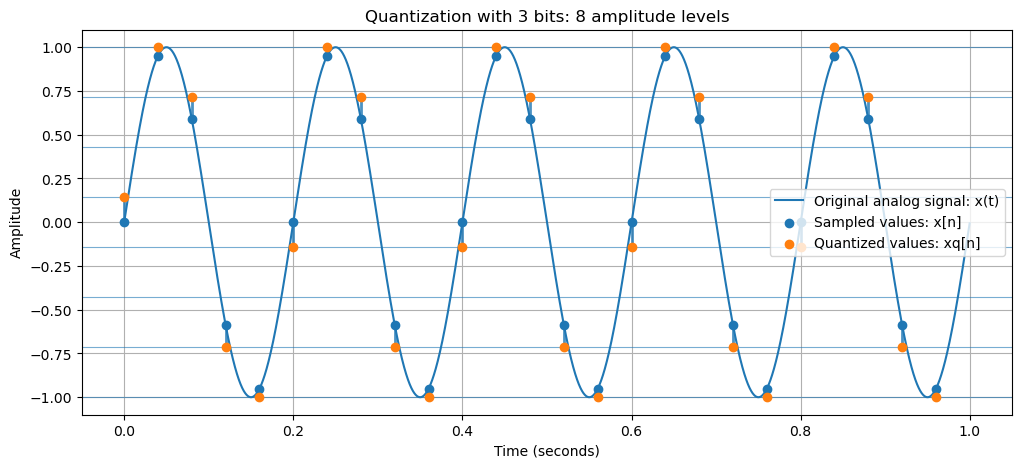

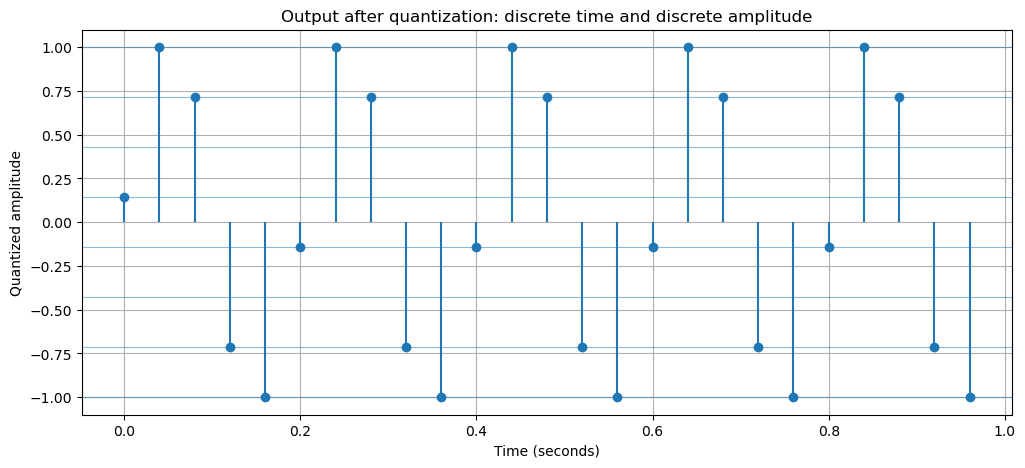

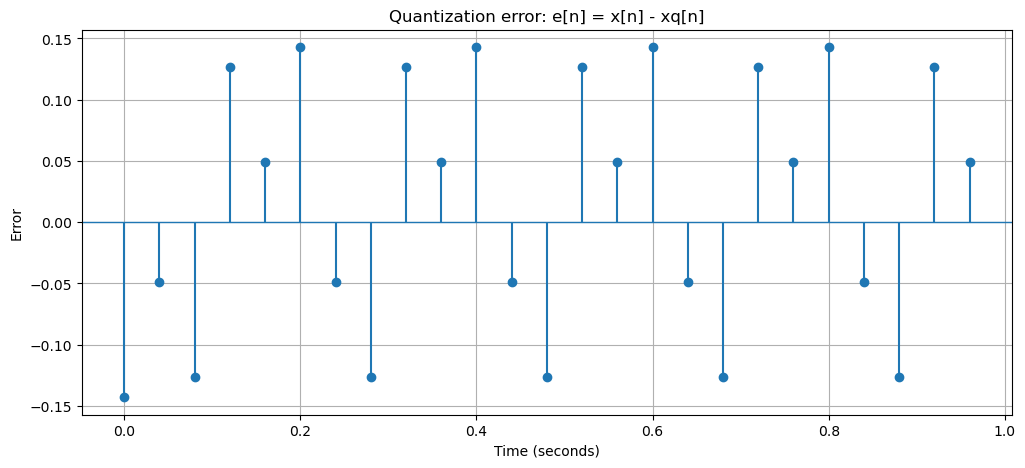

Signal frequency: 5 Hz
Sampling frequency fs: 25 Hz
Sampling interval Ts: 0.04 seconds

ADC bit depth: 3 bits
Number of quantization levels L = 2^n: 8
ADC range R: 2
Minimum amplitude V_min: -1
Maximum amplitude V_max: 1
Quantization step Delta: 0.2857142857142857

First 10 sampled values:
[ 0.00000000e+00  9.51056516e-01  5.87785252e-01 -5.87785252e-01
 -9.51056516e-01 -2.44929360e-16  9.51056516e-01  5.87785252e-01
 -5.87785252e-01 -9.51056516e-01]

First 10 quantized values:
[ 0.14285714  1.          0.71428571 -0.71428571 -1.         -0.14285714
  1.          0.71428571 -0.71428571 -1.        ]

First 10 quantization errors:
[-0.14285714 -0.04894348 -0.12650046  0.12650046  0.04894348  0.14285714
 -0.04894348 -0.12650046  0.12650046  0.04894348]


In [8]:
t_sampled, x_sampled, x_quantized, quantization_error = demonstrate_quantization(
    signal_frequency=5,
    fs=25,
    duration=1.0,
    n_bits=3
)

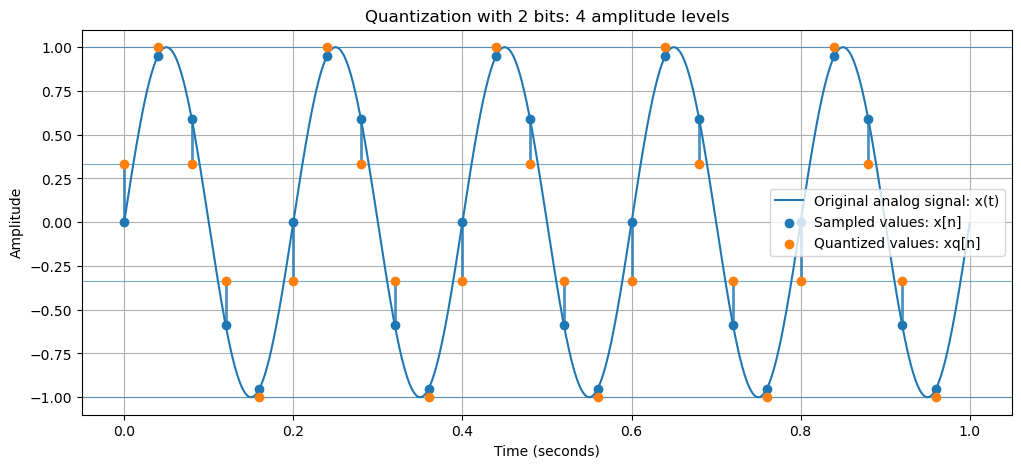

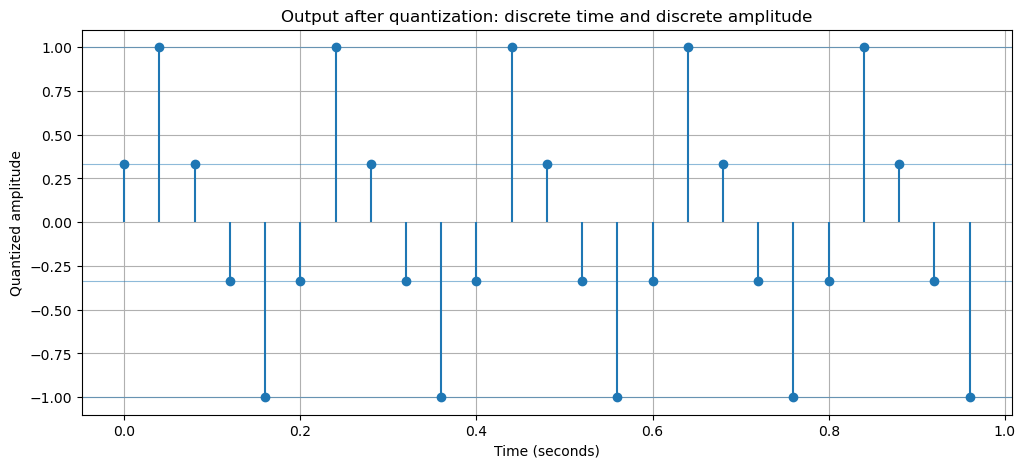

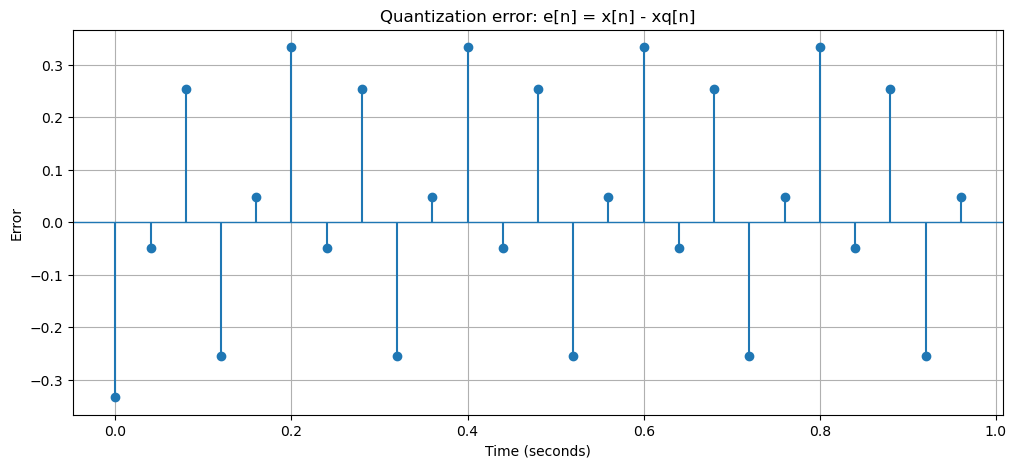

Signal frequency: 5 Hz
Sampling frequency fs: 25 Hz
Sampling interval Ts: 0.04 seconds

ADC bit depth: 2 bits
Number of quantization levels L = 2^n: 4
ADC range R: 2
Minimum amplitude V_min: -1
Maximum amplitude V_max: 1
Quantization step Delta: 0.6666666666666666

First 10 sampled values:
[ 0.00000000e+00  9.51056516e-01  5.87785252e-01 -5.87785252e-01
 -9.51056516e-01 -2.44929360e-16  9.51056516e-01  5.87785252e-01
 -5.87785252e-01 -9.51056516e-01]

First 10 quantized values:
[ 0.33333333  1.          0.33333333 -0.33333333 -1.         -0.33333333
  1.          0.33333333 -0.33333333 -1.        ]

First 10 quantization errors:
[-0.33333333 -0.04894348  0.25445192 -0.25445192  0.04894348  0.33333333
 -0.04894348  0.25445192 -0.25445192  0.04894348]


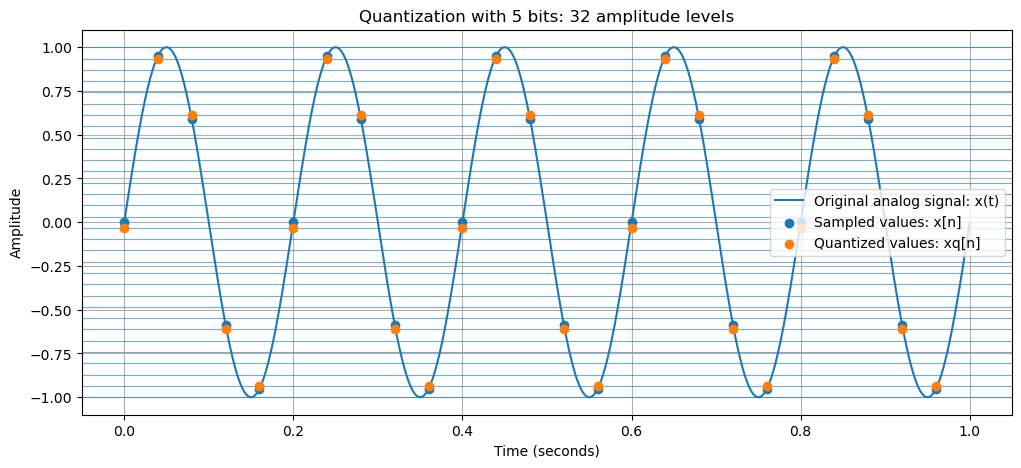

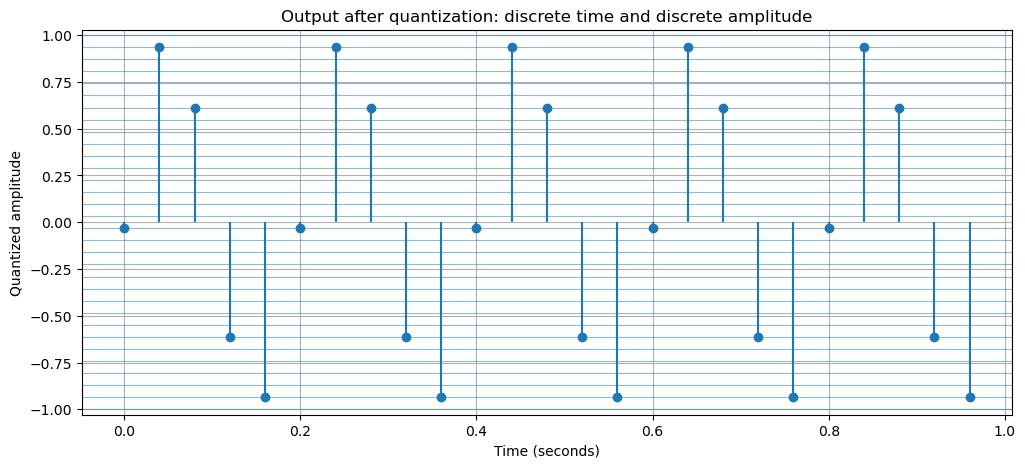

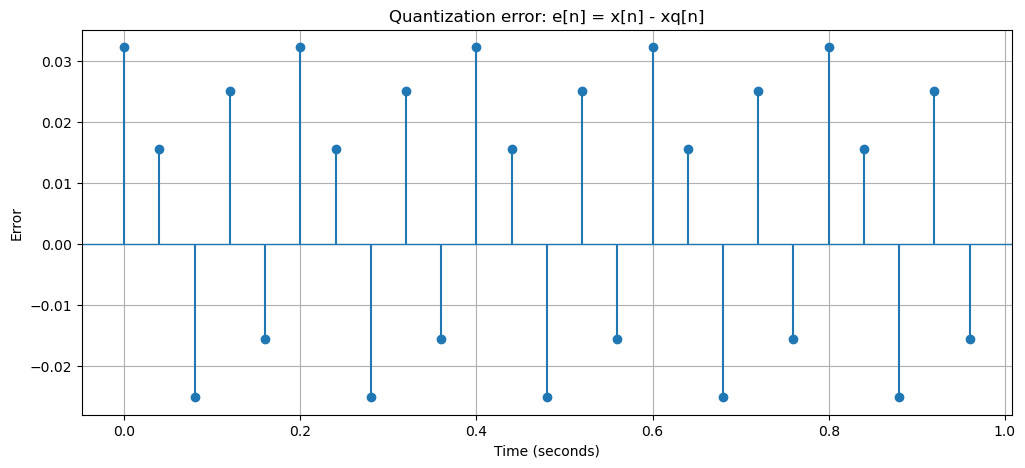

Signal frequency: 5 Hz
Sampling frequency fs: 25 Hz
Sampling interval Ts: 0.04 seconds

ADC bit depth: 5 bits
Number of quantization levels L = 2^n: 32
ADC range R: 2
Minimum amplitude V_min: -1
Maximum amplitude V_max: 1
Quantization step Delta: 0.06451612903225806

First 10 sampled values:
[ 0.00000000e+00  9.51056516e-01  5.87785252e-01 -5.87785252e-01
 -9.51056516e-01 -2.44929360e-16  9.51056516e-01  5.87785252e-01
 -5.87785252e-01 -9.51056516e-01]

First 10 quantized values:
[-0.03225806  0.93548387  0.61290323 -0.61290323 -0.93548387 -0.03225806
  0.93548387  0.61290323 -0.61290323 -0.93548387]

First 10 quantization errors:
[ 0.03225806  0.01557265 -0.02511797  0.02511797 -0.01557265  0.03225806
  0.01557265 -0.02511797  0.02511797 -0.01557265]


(array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
        0.44, 0.48, 0.52, 0.56, 0.6 , 0.64, 0.68, 0.72, 0.76, 0.8 , 0.84,
        0.88, 0.92, 0.96]),
 array([ 0.00000000e+00,  9.51056516e-01,  5.87785252e-01, -5.87785252e-01,
        -9.51056516e-01, -2.44929360e-16,  9.51056516e-01,  5.87785252e-01,
        -5.87785252e-01, -9.51056516e-01, -4.89858720e-16,  9.51056516e-01,
         5.87785252e-01, -5.87785252e-01, -9.51056516e-01, -7.34788079e-16,
         9.51056516e-01,  5.87785252e-01, -5.87785252e-01, -9.51056516e-01,
        -9.79717439e-16,  9.51056516e-01,  5.87785252e-01, -5.87785252e-01,
        -9.51056516e-01]),
 array([-0.03225806,  0.93548387,  0.61290323, -0.61290323, -0.93548387,
        -0.03225806,  0.93548387,  0.61290323, -0.61290323, -0.93548387,
        -0.03225806,  0.93548387,  0.61290323, -0.61290323, -0.93548387,
        -0.03225806,  0.93548387,  0.61290323, -0.61290323, -0.93548387,
        -0.03225806,  0.93548387,  0.61290323, -0

In [9]:
# Low resolution: fewer levels, larger quantization error
demonstrate_quantization(
    signal_frequency=5,
    fs=25,
    duration=1.0,
    n_bits=2
)

# Higher resolution: more levels, smaller quantization error
demonstrate_quantization(
    signal_frequency=5,
    fs=25,
    duration=1.0,
    n_bits=5
)

## <span style="background-color:#d8f8d8; padding:4px;">Digital coding: </span>


* Digital coding is the final phase. Each quantization level is given a distinct binary code during this stage. As a result, the analog signal is converted into a digital representation that can be processed by digital systems.
* An ADC changes a real-world analog signal, like voltage from a sensor, into a digital number that a computer can read.

To know if an ADC is good, we look at a few important things:

* **Resolution:** how detailed the measurement is.
    A higher resolution means the ADC can tell apart very small changes in the signal.
* **Sampling rate:** how often it measures the signal every second.
    A higher sampling rate means it can follow faster-changing signals better.
* **Accuracy:** how close the digital value is to the real input value.
    If it is very accurate, the number it gives is very close to the true signal.
* **Linearity:** how consistently the output changes when the input changes.
    In a good linear ADC, if the input goes up smoothly, the output also goes up smoothly and proportionally.
* **Power consumption:** how much energy it uses.
    This matters a lot in devices that run on batteries, because lower power helps the battery last longer.

So in simple words:
an ADC should measure small changes clearly, sample fast enough, give correct values, respond in a predictable way, and not waste too much power.

## <span style="background-color:#d8f8d8; padding:4px;">How do we determine the number of bits N of an ADC? </span>



We always start from the same core idea: An ADC with $N$ bits can represent:

$2^N$

different amplitude levels.

So the general question is:
> How many different levels do I need to represent my signal with the precision I want?

### <u>General Principle </u>

If the ADC input range is from $V_{\min}$ to $V_{\max}$, then the full range is:

$$R = V_{\max} - V_{\min}$$

If the quantization step is $\Delta$, then the number of levels is approximately:

$$L \approx \frac{R}{\Delta}$$

And we choose $N$ so that:

$$2^N \ge L$$

Equivalently:

$$N \ge \log_2(L)$$

And then we round up to the nearest integer.

### <u>Case 1: We want to resolve changes as small as $\Delta$ </u>

This is the most direct design case. You know:
* The input range
* The smallest change you want to distinguish

#### **Step 1: Compute the signal range**
$$R = V_{\max} - V_{\min}$$



#### **Step 2: Compute how many levels are needed**
$$L \approx \frac{R}{\Delta}$$



#### **Step 3: Choose the smallest number of bits $N$ such that**
$$2^N \ge L$$




### <u>Example 1: Simple Voltage Measurement</u>
Suppose:
* **Input range:** $0$ to $5$ V
* **Smallest change to resolve:** $0.1$ V

**Step 1: Range**
$$R = 5 - 0 = 5\text{ V}$$

**Step 2: Required levels**
$$L \approx \frac{5}{0.1} = 50$$

**Step 3: Choose bits**
We need $2^N \ge 50$:
* $2^5 = 32 \rightarrow$ not enough
* $2^6 = 64 \rightarrow$ enough

$$\boxed{N = 6\text{ bits}}$$


### <u>Example 2: EEG Intuition</u>
Suppose an EEG channel is expected to vary between:
$$-100\ \mu\text{V} \text{ and } +100\ \mu\text{V}$$
And we want to resolve changes of:
$$1\ \mu\text{V}$$

**Step 1: Range**
$$R = 100 - (-100) = 200\ \mu\text{V}$$

**Step 2: Required levels**
$$L \approx \frac{200}{1} = 200$$

**Step 3: Choose bits**
Need $2^N \ge 200$:
* $2^7 = 128 \rightarrow$ not enough
* $2^8 = 256 \rightarrow$ enough

$$\boxed{N = 8\text{ bits}}$$


### <u>Important Note for EEG</u>
In real EEG systems, we often use more than 8 bits, such as **12-bit**, **16-bit**, or **24-bit**, because EEG signals are tiny and we usually want very fine resolution and low quantization error.

## <span style="background-color:#d8f8d8; padding:4px;">Case 2: We know the maximum allowed step size and solve for N </span>


This is mathematically the same idea, but written from the quantization formula. The ADC step size for a uniform quantizer is:

$$\Delta = \frac{V_{\max} - V_{\min}}{2^N}$$

If you know the largest acceptable step size, then solve for $N$.

### <u>Steps</u>

**Step 1: Write the condition**
$$\frac{V_{\max} - V_{\min}}{2^N} \le \Delta_{\max}$$
Where $\Delta_{\max}$ is the largest allowed step.

**Step 2: Rearrange**
$$2^N \ge \frac{V_{\max} - V_{\min}}{\Delta_{\max}}$$

**Step 3: Take $\log_2$**
$$N \ge \log_2\left(\frac{V_{\max} - V_{\min}}{\Delta_{\max}}\right)$$

**Step 4: Round up to the next integer**

### <u>Example 3: Sensor from 0 to 10 V</u>
Suppose:
* **Input range:** $0$ to $10$ V
* **Maximum allowed quantization step:** $0.01$ V

**Step 1**
$$N \ge \log_2\left(\frac{10-0}{0.01}\right)$$

**Step 2**
$$N \ge \log_2(1000)$$

**Step 3**
$$\log_2(1000) \approx 9.97$$

**Step 4: Round up**
$$\boxed{N = 10\text{ bits}}$$

### <u>Check:</u>
* $2^{10} = 1024$ levels.
* Actual step size:
$$\Delta = \frac{10}{1024} \approx 0.00977\text{ V}$$
Which is smaller than $0.01\text{ V}$, so it works.

## <span style="background-color:#d8f8d8; padding:4px;">Case 3: We only have the data in a CSV file</span>


This case is different. Now we do **not** directly know:
* The ADC range used
* The true quantization step
* Whether the values are raw ADC levels or processed signal samples

So here we must be much more careful.

### <u>First important distinction when using CSV data </u>
If you only have an array of numbers, the gaps between values may be irregular for different reasons:
1. The signal itself changes irregularly.
2. The values are noisy.
3. The data were filtered, normalized, scaled, or rounded.
4. The quantizer is not obvious from the final stored values.

From data alone, we usually estimate the bit depth, but we may **not** recover the true original ADC bit depth exactly.

### <u>Case 3A: Ideal case — the values clearly look like quantized levels</u>


Suppose the sorted unique values are:
$$[0.0,\;0.5,\;1.0,\;1.5,\;2.0]$$
The differences are:
$$[0.5,\;0.5,\;0.5,\;0.5]$$
Here the spacing is constant, so it is reasonable to estimate $\Delta \approx 0.5$.

Then:
* **Range:** $R = 2.0 - 0.0 = 2.0$
* **Number of levels:** $L \approx \frac{2.0}{0.5} + 1 = 5$
* **Bits:** $N \approx \lceil \log_2(5) \rceil = 3$

$$\boxed{N \approx 3\text{ bits}}$$
*The $+1$ appears because if you have $L$ equally spaced levels, there are $L-1$ intervals between them.*

### <u>Case 3B: Realistic case — the gaps are not exactly constant</u>


Suppose the unique sorted values are:
$$[0.00,\;0.20,\;0.40,\;0.60,\;0.81,\;1.00]$$
The differences are:
$$[0.20,\;0.20,\;0.20,\;0.21,\;0.19]$$
Here the values suggest the true spacing is **about 0.20**, not exactly.
* Using the **minimum gap** ($0.19$) is possible, but can overestimate bits.
* A better estimate is the **typical gap**, around $0.20$.

Then:
* $R = 1.00 - 0.00 = 1.00$
* $L \approx \frac{1.00}{0.20} + 1 = 6$
* $N \approx \lceil \log_2(6) \rceil = 3$

$$\boxed{N \approx 3\text{ bits}}$$

### <u>Case 3C: Conservative upper-bound from the CSV</u>


This approach is based on the **smallest observed gap**. It answers:
> What is the minimum uniform bit depth needed so that none of the observed unique values merge together?

#### **Steps**
1. **Step 1:** Sort the unique values.
2. **Step 2:** Compute adjacent differences.
3. **Step 3:** Take the smallest nonzero difference: $\Delta_{\min} = \min(\text{adjacent differences})$
4. **Step 4:** Estimate the number of required levels: $L \approx \frac{R}{\Delta_{\min}} + 1$
5. **Step 5:** Estimate bits: $N \approx \lceil \log_2(L) \rceil$

#### E**xample 4: Conservative estimate**
Suppose unique values are: $[0.0,\;0.2,\;0.4,\;0.6,\;0.8,\;0.81,\;1.0]$
Differences: $[0.2,\;0.2,\;0.2,\;0.2,\;0.01,\;0.19]$
* Smallest gap: $\Delta_{\min} = 0.01$
* Range: $R = 1.0 - 0.0 = 1.0$
* $L \approx \frac{1.0}{0.01} + 1 = 101$
* $N \approx \lceil \log_2(101) \rceil = 7$

$$\boxed{N \approx 7\text{ bits}}$$
*This may be an overestimate if that $0.01$ gap is just noise.*

### <u>Case 3D: Robust estimate from the CSV</u>


This is better when data are noisy. Instead of the smallest gap, use the **typical spacing** (most common difference or median of small differences). It answers:
> What seems to be the underlying quantization step?

#### **Example 5: Robust estimate**
Using the same values: $[0.0,\;0.2,\;0.4,\;0.6,\;0.8,\;0.81,\;1.0]$
Differences: $[0.2,\;0.2,\;0.2,\;0.2,\;0.01,\;0.19]$
* The **most common spacing** is clearly about $0.2$.
* Take: $\Delta_{\text{typical}} \approx 0.2$
* $L \approx \frac{1.0}{0.2} + 1 = 6$
* $N \approx \lceil \log_2(6) \rceil = 3$

$$\boxed{N \approx 3\text{ bits}}$$

### <u>How to interpret CSV-based estimates</u>

| Estimate Type | Method | Interpretation |
| :--- | :--- | :--- |
| **Conservative** | Smallest gap | Minimum bit depth needed to keep all observed distinct values separate. |
| **Robust** | Typical spacing | The most likely bit depth, assuming the data come from uniform quantization. |
| **True Original** | N/A | Usually cannot be guaranteed from CSV alone unless data are raw and unprocessed (= the EEG device provides the information). |

## <span style="background-color:#d8f8d8; padding:4px;">Why the Logarithm Appears in ADC Formulas </span>

The use of the base-2 logarithm ($\log_2$) in ADC design is not arbitrary. It exists because the number of levels grows as a **power of 2**, which is a direct result of how binary data is stored.

### <u>1. Why Powers of 2?</u>


A bit can only be $0$ or $1$. Each additional bit doubles the number of possible combinations (codes):
* **1 bit** $\Rightarrow 2^1 = 2$ possibilities (`0`, `1`)
* **2 bits** $\Rightarrow 2^2 = 4$ possibilities (`00`, `01`, `10`, `11`)
* **3 bits** $\Rightarrow 2^3 = 8$ possibilities (`000`, ..., `111`)

In general:
$$N \text{ bits} \Rightarrow 2^N \text{ possible binary codes}$$


### <u>2. Why the Logarithm? </u>

If you know you need $L$ levels to represent your signal, you must find a number of bits $N$ that provides at least that many codes:
$$2^N \ge L$$

To solve for an exponent $N$, we use a **logarithm**. A logarithm answers the question: *"To what exponent must I raise the base to get this number?"*
$$N = \log_2(L)$$

Conceptually, these two statements are identical:
* $2^3 = 8$
* $\log_2(8) = 3$

### <u>3. Deriving the ADC Formula</u>

We determine the number of required levels $L$ by dividing the signal range ($V_{\max} - V_{\min}$) by the desired step size ($\Delta$):
$$L \approx \frac{V_{\max} - V_{\min}}{\Delta}$$

Since an $N$-bit ADC provides $2^N$ levels, we require:
$$2^N \ge \frac{V_{\max} - V_{\min}}{\Delta}$$

Taking the $\log_2$ of both sides:
$$\boxed{N \ge \log_2\left(\frac{V_{\max} - V_{\min}}{\Delta}\right)}$$

### <u>Example: Finding the Number of "Doublings"</u>

Suppose you need **50 levels**.
1.  How many times must you double the number $2$ to reach or exceed $50$?
2.  $2 \rightarrow 4 \rightarrow 8 \rightarrow 16 \rightarrow 32 \rightarrow 64$
3.  That took **6** doublings.

Mathematically, $\log_2(50) \approx 5.64$. Since you cannot have a fraction of a bit, you round up to **6 bits**.

### <u>Comparison Table: Bits to Levels</u>

| Bits ($N$) | Number of Codes ($2^N$) | Usage Context |
| :--- | :--- | :--- |
| 1 | 2 | Simple On/Off (High/Low) |
| 3 | 8 | Very low resolution / Basic logic |
| 8 | 256 | Standard 8-bit microcontrollers |
| 10 | 1,024 | Common Arduino analog inputs |
| 12 | 4,096 | Standard industrial/medical sensors |
| 16 | 65,536 | High-fidelity audio/EEG |

### <u>Final Summary</u>

The $\log_2$ formula is the inverse of the binary expansion. It tells you exactly how many **bit-doublings** are required to achieve the level of detail ($L$) you need for your signal.

### <u>Example:</u>


#### **1. Start with a Real Analog Signal**
An analog signal can take **any value** within a continuous range. For example, imagine a voltage signal that can vary from:

$0 \text{ V to } 5 \text{ V}$

At one moment, the signal might be $2.73 \text{ V}$; at another, $4.12 \text{ V}$.
* The analog signal is **continuous**.
* It is not naturally made of exact steps or binary numbers.

#### **2. First, we Sample the Signal**
The ADC does **not** look at every instant continuously. Instead, it captures the signal at specific points in time.
* At $t_1$: measure voltage.
* At $t_2$: measure again.
* At $t_3$: measure again.

Suppose we measure these analog values: $1.2\text{ V}, 2.7\text{ V}, 4.1\text{ V}$. After sampling, **time is discrete**, but the amplitude is still analog.

#### **3. Then comes Quantization**
The ADC must convert each measured analog value into one of a **finite number of allowed levels**. Because the ADC cannot represent infinitely many values, it divides the input range into specific "steps."

#### **4. Example: 3-bit ADC**
A **3-bit ADC** can produce $2^3 = 8$ different digital levels. If the voltage range is $0 \text{ V to } 5 \text{ V}$, the ADC divides this range into 8 levels.

#### **5. Size of each Quantization Step**
The step size is often called the **resolution** or **LSB (Least Significant Bit) size**.

$$\Delta = \frac{V_{\max}-V_{\min}}{2^N}$$

Where:
* $V_{\max}$ = maximum input voltage
* $V_{\min}$ = minimum input voltage
* $N$ = number of bits

In our example:
$$\Delta = \frac{5-0}{8} = 0.625\text{ V}$$

Each quantization interval is **$0.625\text{ V}$ wide**.

#### **6. Build the Quantization Intervals**
We split the full range into 8 discrete bins:

* **Level 0:** $0$ to $0.625$
* **Level 1:** $0.625$ to $1.25$
* **Level 2:** $1.25$ to $1.875$
* **Level 3:** $1.875$ to $2.5$
* **Level 4:** $2.5$ to $3.125$
* **Level 5:** $3.125$ to $3.75$
* **Level 6:** $3.75$ to $4.375$
* **Level 7:** $4.375$ to $5.0$

#### **7. Assign a Level to the Measured Value**
Suppose one sample is $2.7\text{ V}$. We look for the interval:
* It is above $2.5\text{ V}$.
* It is below $3.125\text{ V}$.

It belongs to **Level 4**. The ADC "rounds" the $2.7\text{ V}$ input to this specific level.

####8. What value does the ADC really store?
The ADC assigns the input to a level, often represented by the **midpoint** of that interval.
For Level 4 ($2.5\text{ V}$ to $3.125\text{ V}$):

$$\text{Midpoint} = \frac{2.5 + 3.125}{2} = 2.8125\text{ V}$$

The difference between the real value ($2.7\text{ V}$) and the quantized value ($2.8125\text{ V}$) is the **quantization error**.

#### **9. Assign a Binary Code to Each Level**
Finally, the ADC encodes the level number into binary. For a 3-bit ADC:

| Level | Binary Code |
| :--- | :--- |
| Level 0 | `000` |
| Level 1 | `001` |
| Level 2 | `010` |
| Level 3 | `011` |
| **Level 4** | **`100`** |
| Level 5 | `101` |
| Level 6 | `110` |
| Level 7 | `111` |

Since $2.7\text{ V}$ was assigned to Level 4, the ADC outputs: **`100`**.

## <span style="background-color:#d8f8d8; padding:4px;">Examples </span>


### <u> Question 1: sampling and quantification:</u>


For each signal, determine the optimal Analog-to-Digital Converter (ADC) configurations required for high-fidelity recording. Specify the dynamic range and the bit depth (quantization levels) necessary to minimize quantization error.

In [1]:
import pandas as pd
import numpy as np
import math

In [2]:
# ------------------------------------------------------------
# 1. Load the CSV files
# ------------------------------------------------------------
# Each CSV file is loaded as a pandas DataFrame.
# A DataFrame is like a table: rows = observations, columns = variables/signals.
sig1 = pd.read_csv("signal1.csv")
sig2 = pd.read_csv("signal2.csv")
sig3 = pd.read_csv("signal3.csv")
# ------------------------------------------------------------
# 2. Print the number of rows in each signal
# ------------------------------------------------------------
# len(dataframe) gives the number of rows.
# This tells us how many samples each signal contains.
print("Number of samples:")
print("sig1:", len(sig1))
print("sig2:", len(sig2))
print("sig3:", len(sig3))
# ------------------------------------------------------------
# 3. Select the first column of each signal
# ------------------------------------------------------------
# sig1.iloc[:, 0] means:
#   :  -> take all rows
#   0  -> take the first column
#
# We do this because the signal values are assumed to be stored
# in the first column of each CSV file.
sig1_values = sig1.iloc[:, 0]
sig2_values = sig2.iloc[:, 0]
sig3_values = sig3.iloc[:, 0]
# ------------------------------------------------------------
# 4. Find the unique amplitude levels in each signal
# ------------------------------------------------------------
# .unique() returns all different values that appear in the signal.
# np.sort(...) sorts them from smallest to largest.
#
# This is useful if we want to inspect quantization levels,
# for example in ADC/digitized signals.
sig1_levels = np.sort(sig1_values.unique())
sig2_levels = np.sort(sig2_values.unique())
sig3_levels = np.sort(sig3_values.unique())
# ------------------------------------------------------------
# 5. Count how many unique levels each signal has
# ------------------------------------------------------------
# .nunique() counts the number of different values.
#
# This number can help estimate how many quantization levels
# are present in the signal.
sig1_L = sig1_values.nunique()
sig2_L = sig2_values.nunique()
sig3_L = sig3_values.nunique()
# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------
print("\nUnique amplitude levels:")
print("sig1 levels:", sig1_levels)
print("sig1 count:", sig1_L)
print("\nsig2 levels:", sig2_levels)
print("sig2 count:", sig2_L)
print("\nsig3 levels:", sig3_levels)
print("sig3 count:", sig3_L)

Number of samples:
sig1: 999
sig2: 999
sig3: 999

Unique amplitude levels:
sig1 levels: [ 0.  5. 10. 15.]
sig1 count: 4

sig2 levels: [ 8.          8.93333333  9.86666667 10.8        11.73333333 12.66666667
 13.6        14.53333333 15.46666667 16.4        17.33333333 18.26666667
 19.2        20.13333333 21.06666667 22.        ]
sig2 count: 16

sig3 levels: [  2.   4.   8.  16.  32.  64. 128. 256.]
sig3 count: 8


#### **signal 1**

In [3]:
# ------------------------------------------------------------
# EEG signal 1: General ADC / quantization approach
# ------------------------------------------------------------
# Goal:
# Estimate the minimum number of ADC bits needed to represent
# the signal without merging two different observed amplitude values
# into the same quantization level.
#
# We use:
#   R      = signal range = max value - min value
#   Delta  = smallest spacing between adjacent observed levels
#   L      = required number of quantization levels
#   b      = required number of bits
#
# Relationship:
#   L ≈ R / Delta
#   2^b >= L
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Extract the signal values from the first column
# ------------------------------------------------------------
# sig1.iloc[:, 0] means:
#   take all rows
#   take the first column
#
# We assume the EEG signal values are stored in the first column.

s1_values = sig1.iloc[:, 0]


# ------------------------------------------------------------
# 2. Find all unique amplitude levels
# ------------------------------------------------------------
# .unique() gives all different values present in the signal.
# np.sort(...) sorts them from smallest to largest.
#
# These unique values are useful because we want to know
# the distinct amplitude levels that already appear in the data.

s1_levels = np.sort(s1_values.unique())


# ------------------------------------------------------------
# 3. Find the maximum, minimum, and range of the signal
# ------------------------------------------------------------
# The range R tells us the total amplitude span that the ADC
# would need to cover.

s1_max = s1_values.max()
s1_min = s1_values.min()
s1_R = s1_max - s1_min


print("s1 max:", s1_max)
print("s1 min:", s1_min)
print("s1 range R:", s1_R)


# ------------------------------------------------------------
# 4. Compute the spacing between adjacent unique levels
# ------------------------------------------------------------
# np.diff(s1_levels) subtracts each level from the next one.
#
# Example:
# levels = [0.1, 0.2, 0.5]
# diffs  = [0.1, 0.3]
#
# These differences tell us how close two observed values are.

s1_diffs = np.diff(s1_levels)


# ------------------------------------------------------------
# 5. Choose the smallest observed spacing as the required Delta
# ------------------------------------------------------------
# We use the minimum adjacent spacing because we want the ADC
# resolution to be fine enough to distinguish even the closest
# pair of observed values.
#
# If Delta were larger than this minimum spacing, two different
# observed signal values could fall into the same quantization bin.
#
# Important:
# This assumes we want to preserve every distinct observed value.
# In real ADC design, Delta may also be chosen based on acceptable
# noise, error tolerance, or biological measurement precision.

s1_delta_req = np.min(s1_diffs)


# ------------------------------------------------------------
# 6. Estimate the required number of uniform quantization levels
# ------------------------------------------------------------
# If the total range is R and the spacing between levels is Delta,
# then the number of intervals is approximately:
#
#   R / Delta
#
# But the number of levels is the number of intervals plus 1.
#
# Example:
# levels: 0, 1, 2, 3
# range R = 3
# Delta = 1
# intervals = 3
# levels = 4
#
# Therefore:
#
#   L = ceil(R / Delta) + 1

s1_L = math.ceil(s1_R / s1_delta_req) + 1


# ------------------------------------------------------------
# 7. Compute the required bit depth
# ------------------------------------------------------------
# An ADC with b bits can represent:
#
#   2^b
#
# different digital codes.
#
# So we need:
#
#   2^b >= L
#
# Solving for b:
#
#   b >= log2(L)
#
# Since b must be an integer, we round up using ceil.

s1_b = math.ceil(math.log2(s1_L))


# ------------------------------------------------------------
# 8. Print the final results
# ------------------------------------------------------------

print("\nAdjacent spacings:", s1_diffs)
print("Smallest required spacing Delta:", s1_delta_req)
print("Required number of uniform levels L:", s1_L)
print("Required bit depth b:", s1_b)
print("Available codes with that bit depth:", 2**s1_b)

s1 max: 15.0
s1 min: 0.0
s1 range R: 15.0

Adjacent spacings: [5. 5. 5.]
Smallest required spacing Delta: 5.0
Required number of uniform levels L: 4
Required bit depth b: 2
Available codes with that bit depth: 4


#### **signal 2**

In [4]:
# ------------------------------------------------------------
# Signal 2: General ADC / quantization approach
# ------------------------------------------------------------
# Goal:
# Estimate the minimum number of ADC bits needed to represent
# the observed amplitude values in signal 2.
#
# We use:
#
#   R      = signal range = max value - min value
#   Delta  = smallest spacing between adjacent observed levels
#   L      = required number of uniform quantization levels
#   b      = required bit depth
#
# Main idea:
#
#   2^b >= L
#
# because an ADC with b bits can represent 2^b different codes.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Extract signal values from the first column
# ------------------------------------------------------------
# sig2.iloc[:, 0] means:
#   :  -> take all rows
#   0  -> take the first column
#
# We assume the signal values are stored in the first column.

s2_values = sig2.iloc[:, 0]


# ------------------------------------------------------------
# 2. Find all unique amplitude levels
# ------------------------------------------------------------
# .unique() returns all different values that appear in the signal.
# np.sort(...) orders them from smallest to largest.
#
# This helps us inspect the observed quantization/amplitude levels.

s2_levels = np.sort(s2_values.unique())


# ------------------------------------------------------------
# 3. Compute maximum, minimum, and range
# ------------------------------------------------------------
# The range R is the full amplitude span of the signal.
#
#   R = max - min

s2_max = s2_values.max()
s2_min = s2_values.min()
s2_R = s2_max - s2_min


print("s2 max:", s2_max)
print("s2 min:", s2_min)
print("s2 range R:", s2_R)


# ------------------------------------------------------------
# 4. Compute adjacent spacings between unique levels
# ------------------------------------------------------------
# np.diff(s2_levels) computes the difference between consecutive
# sorted levels.
#
# Example:
# levels = [0.1, 0.2, 0.5]
# diffs  = [0.1, 0.3]

s2_diffs = np.diff(s2_levels)


# ------------------------------------------------------------
# 5. Choose the smallest observed spacing as Delta
# ------------------------------------------------------------
# We use the minimum adjacent spacing because we want the ADC
# resolution to be fine enough to separate even the closest two
# observed signal values.
#
# If Delta were larger than this smallest spacing, then two
# different observed amplitudes could be mapped to the same
# quantization level.

s2_delta_req = np.min(s2_diffs)


# ------------------------------------------------------------
# 6. Estimate the required number of uniform levels
# ------------------------------------------------------------
# The number of intervals needed across the range is:
#
#   R / Delta
#
# But the number of levels is intervals + 1.
#
# Example:
# levels: 0, 1, 2, 3
# range R = 3
# Delta = 1
# intervals = 3
# levels = 4
#
# Therefore:
#
#   L = ceil(R / Delta) + 1

s2_L = math.ceil(s2_R / s2_delta_req) + 1


# ------------------------------------------------------------
# 7. Compute the required bit depth
# ------------------------------------------------------------
# An ADC with b bits has:
#
#   2^b
#
# possible digital codes.
#
# We need enough codes to cover all required levels:
#
#   2^b >= L
#
# Therefore:
#
#   b >= log2(L)
#
# Since bits must be a whole number, we round up.

s2_b = math.ceil(math.log2(s2_L))


# ------------------------------------------------------------
# 8. Print final results
# ------------------------------------------------------------

print("\nAdjacent spacings:", s2_diffs)
print("Smallest required spacing Delta:", s2_delta_req)
print("Required number of uniform levels L:", s2_L)
print("Required bit depth b:", s2_b)
print("Available codes with that bit depth:", 2**s2_b)

s2 max: 22.0
s2 min: 8.0
s2 range R: 14.0

Adjacent spacings: [0.93333333 0.93333333 0.93333333 0.93333333 0.93333333 0.93333333
 0.93333333 0.93333333 0.93333333 0.93333333 0.93333333 0.93333333
 0.93333333 0.93333333 0.93333333]
Smallest required spacing Delta: 0.93333333333333
Required number of uniform levels L: 17
Required bit depth b: 5
Available codes with that bit depth: 32


#### **signal 3**

In [6]:
# ------------------------------------------------------------
# Signal 3: General ADC / quantization approach
# ------------------------------------------------------------
# Goal:
# Estimate the minimum number of ADC bits needed to represent
# the observed amplitude values in signal 3.
#
# We use:
#
#   R      = signal range = max value - min value
#   Delta  = smallest spacing between adjacent observed levels
#   L      = required number of uniform quantization levels
#   b      = required bit depth
#
# Main ADC relationship:
#
#   2^b >= L
#
# because an ADC with b bits can represent 2^b digital codes.
# ------------------------------------------------------------


# ------------------------------------------------------------
# 1. Extract signal values from the first column
# ------------------------------------------------------------
# sig3.iloc[:, 0] means:
#   :  -> take all rows
#   0  -> take the first column
#
# We assume the signal values are stored in the first column.

s3_values = sig3.iloc[:, 0]


# ------------------------------------------------------------
# 2. Find all unique amplitude levels
# ------------------------------------------------------------
# .unique() returns all different amplitude values
# that appear in the signal.
#
# np.sort(...) orders those values from smallest to largest.

s3_levels = np.sort(s3_values.unique())


# ------------------------------------------------------------
# 3. Compute maximum, minimum, and range
# ------------------------------------------------------------
# The signal range R is:
#
#   R = max - min
#
# This tells us the full amplitude span that the ADC must cover.

s3_max = s3_values.max()
s3_min = s3_values.min()
s3_R = s3_max - s3_min


print("s3 max:", s3_max)
print("s3 min:", s3_min)
print("s3 range R:", s3_R)


# ------------------------------------------------------------
# 4. Compute adjacent spacings between unique levels
# ------------------------------------------------------------
# np.diff(s3_levels) computes the difference between consecutive
# sorted amplitude levels.
#
# Example:
#
# levels = [0.1, 0.2, 0.5]
# diffs  = [0.1, 0.3]
#
# These differences tell us how close the observed values are.

s3_diffs = np.diff(s3_levels)


# ------------------------------------------------------------
# 5. Choose the smallest observed spacing as Delta
# ------------------------------------------------------------
# We use the smallest adjacent spacing because we want the ADC
# resolution to be fine enough to separate even the closest pair
# of observed signal values.
#
# If Delta were larger than this smallest spacing, two different
# observed amplitudes could fall into the same quantization level.

s3_delta_req = np.min(s3_diffs)


# ------------------------------------------------------------
# 6. Estimate the required number of uniform quantization levels
# ------------------------------------------------------------
# If the total amplitude range is R and the spacing between
# neighboring quantization levels is Delta, then:
#
#   number of intervals ≈ R / Delta
#
# But the number of levels is one more than the number of intervals.
#
# Example:
#
# levels: 0, 1, 2, 3
# range R = 3
# Delta = 1
# intervals = 3
# levels = 4
#
# Therefore:
#
#   L = ceil(R / Delta) + 1

s3_L = math.ceil(s3_R / s3_delta_req) + 1


# ------------------------------------------------------------
# 7. Compute the required bit depth
# ------------------------------------------------------------
# An ADC with b bits can represent:
#
#   2^b
#
# different digital codes.
#
# So we need:
#
#   2^b >= L
#
# Solving for b:
#
#   b >= log2(L)
#
# Because bit depth must be an integer, we round up.

s3_b = math.ceil(math.log2(s3_L))


# ------------------------------------------------------------
# 8. Print final results
# ------------------------------------------------------------

print("\nAdjacent spacings:", s3_diffs)
print("Smallest required spacing Delta:", s3_delta_req)
print("Required number of uniform levels L:", s3_L)
print("Required bit depth b:", s3_b)
print("Available codes with that bit depth:", 2**s3_b)

s3 max: 256.0
s3 min: 2.0
s3 range R: 254.0

Adjacent spacings: [  2.   4.   8.  16.  32.  64. 128.]
Smallest required spacing Delta: 2.0
Required number of uniform levels L: 128
Required bit depth b: 7
Available codes with that bit depth: 128


**END**